   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 42.7 MB/s eta 0:00:00


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


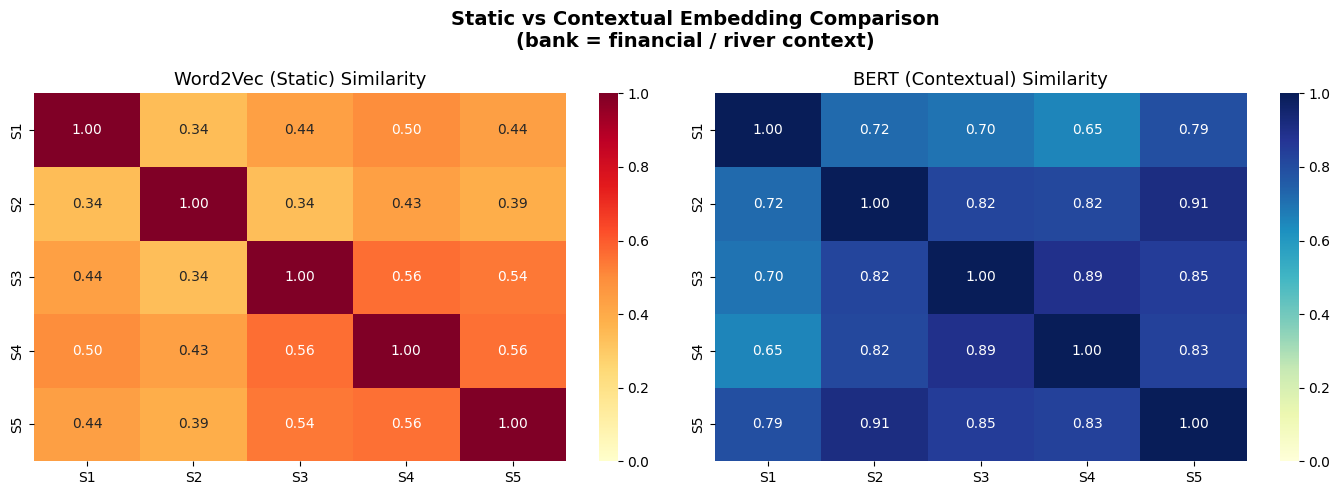


Sentence Reference:
  S1: The bank can guarantee deposits will eventually cover future tuition costs.
  S2: I went to the bank to withdraw money.
  S3: The river bank was covered with beautiful flowers.
  S4: He sat on the bank of the river fishing.
  S5: The bank approved my loan application today.

'bank' Word2Vec vector (first 5 dims) — always identical:
[-0.00887444  0.00425502  0.00587241  0.00700309  0.00738936]

BERT cosine similarity of 'bank' (financial vs river): 0.5186
(Lower score = BERT distinguishes context; Word2Vec would give 1.0)


In [1]:
!pip install transformers gensim -q

import numpy as np
import torch
from transformers import BertTokenizer, BertModel
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

# Sample dataset
sentences = [
    "The bank can guarantee deposits will eventually cover future tuition costs.",
    "I went to the bank to withdraw money.",
    "The river bank was covered with beautiful flowers.",
    "He sat on the bank of the river fishing.",
    "The bank approved my loan application today."
]

tokenized = [s.lower().split() for s in sentences]

# ── Word2Vec (Static Embeddings) ──────────────────────────────────────────────
w2v_model = Word2Vec(tokenized, vector_size=100, window=5, min_count=1, workers=4, epochs=100)

def get_w2v_sentence_embedding(sentence):
    words = sentence.lower().split()
    vecs = [w2v_model.wv[w] for w in words if w in w2v_model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(100)

w2v_embeddings = np.array([get_w2v_sentence_embedding(s) for s in sentences])

# ── BERT (Contextual Embeddings) ──────────────────────────────────────────────
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')
bert_model.eval()

def get_bert_embedding(sentence):
    inputs = tokenizer(sentence, return_tensors='pt', truncation=True, max_length=128)
    with torch.no_grad():
        outputs = bert_model(**inputs)
    return outputs.last_hidden_state[:, 0, :].squeeze().numpy()

bert_embeddings = np.array([get_bert_embedding(s) for s in sentences])

# ── Cosine Similarity Matrices ────────────────────────────────────────────────
w2v_sim  = cosine_similarity(w2v_embeddings)
bert_sim = cosine_similarity(bert_embeddings)

labels = [f"S{i+1}" for i in range(len(sentences))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(w2v_sim, annot=True, fmt=".2f", xticklabels=labels,
            yticklabels=labels, cmap='YlOrRd', ax=axes[0], vmin=0, vmax=1)
axes[0].set_title("Word2Vec (Static) Similarity", fontsize=13)

sns.heatmap(bert_sim, annot=True, fmt=".2f", xticklabels=labels,
            yticklabels=labels, cmap='YlGnBu', ax=axes[1], vmin=0, vmax=1)
axes[1].set_title("BERT (Contextual) Similarity", fontsize=13)

plt.suptitle("Static vs Contextual Embedding Comparison\n(bank = financial / river context)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Print sentence reference ──────────────────────────────────────────────────
print("\nSentence Reference:")
for i, s in enumerate(sentences):
    print(f"  S{i+1}: {s}")

# ── Word-level: static embedding for 'bank' (same every time) ────────────────
print("\n'bank' Word2Vec vector (first 5 dims) — always identical:")
print(w2v_model.wv['bank'][:5])

# ── Word-level: contextual embedding for 'bank' across two sentences ──────────
def get_word_embedding_bert(sentence, target_word):
    inputs = tokenizer(sentence, return_tensors='pt')
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    with torch.no_grad():
        outputs = bert_model(**inputs)
    hidden = outputs.last_hidden_state[0]
    for i, t in enumerate(tokens):
        if t == target_word:
            return hidden[i].numpy()
    return None

vec1 = get_word_embedding_bert(sentences[1], 'bank')
vec2 = get_word_embedding_bert(sentences[2], 'bank')

if vec1 is not None and vec2 is not None:
    sim = cosine_similarity([vec1], [vec2])[0][0]
    print(f"\nBERT cosine similarity of 'bank' (financial vs river): {sim:.4f}")
    print("(Lower score = BERT distinguishes context; Word2Vec would give 1.0)")

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for f in files:
        if f.endswith('.ipynb'):
            print(os.path.join(root, f))

/content/drive/MyDrive/Colab Notebooks/NLPMMM20.ipynb
/content/drive/MyDrive/Colab Notebooks/DeepLearn_EXPT1.ipynb
/content/drive/MyDrive/Colab Notebooks/DLP_2.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled1.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled3.ipynb
/content/drive/MyDrive/Colab Notebooks/Research&SeminarLLM-PartII.ipynb
/content/drive/MyDrive/Colab Notebooks/SeminarResearch2LLM.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled2.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled4.ipynb
/content/drive/MyDrive/Colab Notebooks/llm on huggingface.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled5.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled7.ipynb
/content/drive/MyDrive/Colab Notebooks/medicalQ&Aversion1.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled6.ipynb
/content/drive/MyDrive/Colab Notebooks/Tinyllama.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled8.ipynb
/content/drive/MyDr

In [ ]:
import json
from google.colab import files

notebook_path = "/content/drive/MyDrive/Colab Notebooks/NLPMMM18.ipynb"  # paste your path here

with open(notebook_path, "r") as f:
    nb = json.load(f)

for cell in nb.get("cells", []):
    if "metadata" in cell:
        cell["metadata"].pop("widgets", None)

if "widgets" in nb.get("metadata", {}):
    del nb["metadata"]["widgets"]

# Save fixed copy to /content (not Drive)
fixed_path = "/content/NLPMMM18.ipynb"
with open(fixed_path, "w") as f:
    json.dump(nb, f, indent=1)

print("Fixed! Downloading now...")
files.download(fixed_path)